# 25 · E1l: E1 re-decided on a fairly fitted ladder

**Where Notebook 24 left off.** A slow current did not help the linear model. The finding that mattered was a different one: **E1's wiring-only L0 was under-fitted.**

| held-out FEVE, both strains | E1 fit | + 300 steps from it |
|---|---|---|
| L0 (wiring + signs, linear) | 0.295 | **0.375** (Notebook 24) |
| L1 (+ sigmoid synapses) | 0.268–0.298 | +0.002–0.004 (Notebook 22) |

* In E1, every rung had the same *total* budget (1000 steps in `laptop` mode). L1 grew from the best of 3 restarts, L2–L4 from L1 by a nested warm start, and L0 and the black box B from a single start.
* Refined L0 is the best model of the atlas so far: it beats every mechanistic rung and B. With it, all three of E1's rules give **L0**.
* So the gaps E1's rules compared were partly differences of **fit quality**, not of mechanism. A rung that 300 more steps can move by 0.08 was not at the optimum of its family, and nothing guarantees that the other rungs (L2–L4, B) were.

**This notebook gives every model the same treatment and decides again.**
* **Round 1:** every rung (L0, L0s, L1, L1s, L2, L3, L4) and the black box B gets `STEPS` more optimizer steps from its E1 fit, on the same training pairs with the same learning rate and a fresh warm-up/cosine schedule. That is exactly what moved L0. The refinements of L0, L0s, L1 and L1s already made in Notebooks 22 and 24 are reused, and L2, L3, L4 and B are new.
* **Round 2:** every model gets `STEPS` more from its round-1 fit. This checks convergence: if the training fit still moves, the comparison is still about optimization.
* **Decision:** E1's three rules (sufficiency, necessity, calibrated v4) and the black-box rule on the round-2 ladder, both strains and wild type.

*(Package 0.21.0: a warm-started black box keeps its read-out. Before, `fit` rescaled B's read-out towards zero even when given an initial fit; E1 never warm-started B, so no earlier result is affected.)*

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 21, 0), \
    f"Notebook 25 needs closurebench >= 0.21.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
N_BOOT, THRESHOLD = 2000, 0.05
TAG = "" if MODE == "full" else f"_{MODE}"
E1_TAG = "_laptop" if MODE == "smoke" else TAG
PRIOR = "laptop" if MODE == "smoke" else MODE              # folder of Notebooks 22/24 checkpoints
LADDER0 = ("L0", "L1", "L2", "L3", "L4"); LADDER2 = ("L0", "L0s", "L1", "L1s", "L2", "L3", "L4"); RUNGS = LADDER2 + ("B",)
STEPS = {"smoke": 8, "laptop": 300, "full": 1000}[MODE]
SLOW_DEFAULT = (0.1, 10.0)                                   # Notebook 24's grid choice; used only if no earlier fit exists

def to_np(p):
    q = jax.tree_util.tree_map(np.asarray, dict(p))
    if "n_heads" in q: q["n_heads"] = int(q["n_heads"])
    return q
def to_jnp(p):
    q = {k: (v if k == "n_heads" else jax.tree_util.tree_map(jnp.asarray, v)) for k, v in dict(p).items()}
    if "n_heads" in q: q["n_heads"] = int(q["n_heads"])
    return q
def family(L): return L                                      # each rung is its own model family

try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    c = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"])
    E1_PRED = {k: v for k, v in np.load(os.path.join(RESULTS, f"E1_heldout_predictions{E1_TAG}.npz")).items()}
    ck1 = os.path.join(RESULTS, f"e1_checkpoints{E1_TAG}")
    def _e1(f, L):                                           # E1's final fit (L4, the deepest chain rung, has no "final" stage)
        for nm in (f"fold{f}_{L}_final.pkl", f"fold{f}_{L}_chain.pkl"):
            pth = os.path.join(ck1, nm)
            if os.path.exists(pth): return to_np(pickle.load(open(pth, "rb"))["params"])
        raise FileNotFoundError(f"no E1 checkpoint for fold {f}, rung {L} in {ck1}")
    E1_FITS = [{L: _e1(f, L) for L in LADDER0 + ("B",)} for f in range(len(folds))]
    LR = float(c.get("lr", 1e-2))
    d9 = os.path.join(RESULTS, f"E1e_result{E1_TAG}.json")
    DELTA = json.load(open(d9))["delta"] if os.path.exists(d9) else {}
    SOURCE = f"E1 ({E1_TAG.strip('_') or 'full'}) fits + Notebooks 22/24 refinements"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("E1 results not found (", err, ") -> CODE-PATH TEST ONLY on a synthetic worm; 'E1 fits' are made here with a few steps")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=24, S=10, seed=1), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = M_.kfold_pairs(ds, 2, 0); LR = 1e-2
    E1_FITS = []
    for f, test in enumerate(folds):
        E1_FITS.append({L: to_np(lad.fit(L, ds, train_mask=~test & ds.mask(), steps=STEPS, lr=LR, verbose=0, st=st, cfg=cfg, seed=f)[0])
                        for L in LADDER0 + ("B",)})
    E1_PRED = None; DELTA = {"repeat": 0.01}; SOURCE = "synthetic (code path only)"
print(f"source: {SOURCE} | {ds.N} neurons, {ds.S} stimuli, strains {ds.strains} | {len(folds)} folds | "
      f"{STEPS} steps per round, lr {LR} | calibrated deltas {DELTA}")

source: E1 (laptop) fits + Notebooks 22/24 refinements | 120 neurons, 120 stimuli, strains ('wt', 'unc31') | 5 folds | 300 steps per round, lr 0.02 | calibrated deltas {'repeat': 0.0, 'long': 0.0025557642078298222}


### Pre-registration (before §1)

Recorded in `results/E1l_preregistration*.json`. Folds, metric and bootstrap are E1's.

**Budget.** Every model gets the same two rounds of `STEPS` steps (300 in `laptop` mode, 1000 in `full`), on its fold's training pairs, with E1's learning rate.
* Round 1 starts from the E1 fit. `L0s` and `L1s` start from the E1 fit of L0 / L1 plus the slow current chosen on training pairs (Notebooks 24 / 22).
* Round 2 starts from round 1.
* **Guard:** a round is kept only if it does not lower that model's *training*-pair FEVE; otherwise the model stays at its start. This uses training data only. A warm restart of Adam can throw a model, the black box especially, out of its basin.

**Rules.** Unless noted, the scores are held-out FEVE, both strains, on round 2.
* **CONVERGED:** no model's *training*-pair FEVE rises by more than 0.01 from round 1 to round 2. Training fit, not held-out fit, is the convergence criterion: held-out FEVE may fall while the optimizer still improves.
* **DECISIONS_STABLE:** E1's three decisions on the extended ladder are the same after round 1 and round 2.
* **VERDICT_L0** (primary): on the extended ladder (L0, L0s, L1, L1s, L2, L3, L4), the necessity rule and rule v4 (every δ) both give **L0**. E1's verdict survives fair fitting.
* **SLOW_HELPS_L0 / SLOW_HELPS_L1:** `L0s` beats L0, and `L1s` beats L1. In each case the 95 % CI lower bound must be > 0.
* **OUTCOME_C / OUTCOME_C_WT:** E1's black-box rule holds on both strains / on WT pairs. That is, the 2.5th percentile of FEVE(B) − FEVE(L\*) is > 0.05, with L\* the sufficiency decision on the extended ladder.

**Reported:**
* the original ladder (L0–L4) decisions;
* every rung's training and held-out FEVE in rounds 0 (E1), 1 and 2.

In [3]:
prereg = os.path.join(RESULTS, f"E1l_preregistration{TAG}.json")
plan = {"experiment": "E1l equal-budget refinement of every rung, then E1's rules", "mode": MODE,
        "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(), "source": SOURCE,
        "rungs": list(RUNGS), "steps_per_round": STEPS, "rounds": 2, "lr": LR, "n_boot": N_BOOT,
        "guard": "a round is kept only if it does not lower the model's training-pair FEVE (else the start is kept)",
        "CONVERGED": "every model's training-pair FEVE (both strains) rises by < 0.01 from round 1 to round 2",
        "DECISIONS_STABLE": "L*, L_needed and v4 (every delta) on the extended ladder identical after rounds 1 and 2",
        "VERDICT_L0": "round 2, extended ladder, both strains: L_needed == L0 and v4 == L0 for every delta",
        "SLOW_HELPS_L0": "round 2: L0s - L0 held-out, CI lower bound > 0", "SLOW_HELPS_L1": "round 2: L1s - L1, CI lower bound > 0",
        "OUTCOME_C": "round 2, both strains: 2.5th pct of FEVE(B) - FEVE(L*) > 0.05",
        "OUTCOME_C_WT": "round 2, WT pairs: 2.5th pct of FEVE(B) - FEVE(L*_WT) > 0.05"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1l_preregistration_laptop.json


## 1 · Two rounds of refinement for every model (checkpointed)

Each fit is saved as soon as it finishes, so an interrupted run resumes where it stopped. `laptop` mode needs 4 × 5 = 20 new round-1 fits (L2, L3, L4 and B) and 8 × 5 = 40 round-2 fits, plus one training-set prediction per fit for the guard. The slowest are L3 and L4, a few minutes each on an M1. Round-1 refinements of L0, L0s, L1 and L1s are loaded from Notebooks 24 and 22 when present.

In [4]:
CK = os.path.join(RESULTS, "e1l_ck", MODE); os.makedirs(CK, exist_ok=True)
def split(f):
    test = folds[f]; train = np.zeros_like(test)
    for g in range(len(folds)):
        if g != f: train |= folds[g]
    return train, test
def slow_init(p, level, rho, tau_n):
    q = lad.extend_params(to_jnp(p), level, st, jax.random.PRNGKey(0))
    q["rho_s"] = jnp.array(float(np.log(rho / (0.9 - rho)))); q["tau_ns"] = jnp.array(lad.inv_sp(max(tau_n - lad.TAU_MIN, 0.05)))
    return to_np(q)
def full_pred(L, p):
    cols = np.arange(ds.S)
    return np.asarray(lad.predict(family(L), to_jnp(p), st, ds.stim, ds.strains, cfg, cols, proto=lad.proto_cols(ds, cols)))
def refine(name, L, init, f):
    pth = os.path.join(CK, f"fold{f}_{name}.pkl")
    if os.path.exists(pth):
        return pickle.load(open(pth, "rb"))["params"]
    train, _ = split(f); t0 = time.time()
    p, losses = lad.fit(family(L), ds, train_mask=train & ds.mask(), init=to_jnp(init), steps=STEPS, lr=LR, verbose=0, st=st, cfg=cfg, seed=f)
    p = to_np(p); dt = time.time() - t0
    pickle.dump({"params": p, "loss_first": float(losses[0]), "loss_last": float(losses[-1]), "seconds": dt}, open(pth, "wb"))
    print(f"fold {f} {name:9s}: training loss {losses[0]:.4f} -> {losses[-1]:.4f}  ({dt:.0f} s)", flush=True)
    return p
def prior(path, key=None):
    if not os.path.exists(path): return None
    d = pickle.load(open(path, "rb"))
    return to_np(d[key] if key else d)

TRF = {}                                                     # training-pair FEVE (both strains), memoised by (round, fold, rung)
def tf(r, f, L, p):
    if (r, f, L) not in TRF:
        TRF[(r, f, L)] = float(M_.feve(full_pred(L, p), ds, extra_mask=split(f)[0]))
    return TRF[(r, f, L)]
KEPT_START = []
def guard(r_from, r_to, f, L, start, result):
    """Registered: a round is kept only if it does not lower the model's training-pair FEVE."""
    if tf(r_to, f, L, result) >= tf(r_from, f, L, start):
        return result
    KEPT_START.append((r_to, f, L)); TRF[(r_to, f, L)] = TRF[(r_from, f, L)]
    print(f"fold {f} {L}: round {r_to} lowered the training fit -> start kept", flush=True)
    return start

R1, R2, R1_FROM, SEL_PRIOR = [], [], {}, {}
for f in range(len(folds)):
    e1 = E1_FITS[f]; r1 = {}
    nb24 = os.path.join(RESULTS, "e1k_ck", PRIOR, f"fold{f}.pkl"); nb22 = os.path.join(RESULTS, "e1i_ck", PRIOR)
    found = {"L0": prior(nb24, "L0_refit"), "L0s": prior(nb24, "L0s"),
             "L1": prior(os.path.join(nb22, f"fold{f}_L1_refit.pkl")), "L1s": prior(os.path.join(nb22, f"fold{f}_L1s_sel.pkl"))}
    if os.path.exists(nb24):
        SEL_PRIOR[(f, "L0s")] = tuple(pickle.load(open(nb24, "rb"))["sel"][0])
    for L in RUNGS:
        if L in ("L0s", "L1s"):
            start = slow_init(e1[L[:2]], L, *(SEL_PRIOR.get((f, L)) or SLOW_DEFAULT)); r0 = "start"
        else:
            start = e1[L]; r0 = "E1"
        if found.get(L) is not None:
            res = found[L]; R1_FROM[L] = "Notebook 24" if L.startswith("L0") else "Notebook 22"
        else:
            res = refine(f"{L}_r1", L, start, f); R1_FROM[L] = "here"
        r1[L] = guard(r0, "r1", f, L, start, res) if r0 == "E1" else res
        if r0 == "start": tf("r1", f, L, r1[L])
    R1.append(r1)
    R2.append({L: guard("r1", "r2", f, L, r1[L], refine(f"{L}_r2", L, r1[L], f)) for L in RUNGS})
print("round-1 sources:", R1_FROM, "| rounds that lowered the training fit (start kept):", KEPT_START or "none")
for L in ("L0s", "L1s"):
    rho = [0.9 / (1 + np.exp(-float(R2[f][L]["rho_s"]))) for f in range(len(folds))]
    tau = [lad.TAU_MIN + float(np.log1p(np.exp(R2[f][L]["tau_ns"]))) for f in range(len(folds))]
    print(f"{L} after round 2: rho {np.round(rho, 3)}, tau_n {np.round(tau, 1)} s")

fold 0 L2_r1    : training loss 0.8369 -> 0.8322  (94 s)
fold 0 L3_r1    : training loss 0.8142 -> 0.8079  (165 s)
fold 0 L4_r1    : training loss 0.8139 -> 0.8003  (124 s)
fold 0 B_r1     : training loss 0.5227 -> 0.4562  (48 s)
fold 0 L0_r2    : training loss 0.8643 -> 0.8536  (28 s)
fold 0 L0s_r2   : training loss 0.8675 -> 0.8563  (36 s)
fold 0 L1_r2    : training loss 0.8345 -> 0.8304  (84 s)
fold 0 L1s_r2   : training loss 0.8310 -> 0.8253  (85 s)
fold 0 L2_r2    : training loss 0.8290 -> 0.8256  (92 s)
fold 0 L3_r2    : training loss 0.8045 -> 0.7933  (109 s)
fold 0 L4_r2    : training loss 0.7956 -> 0.7911  (103 s)
fold 0 B_r2     : training loss 0.4489 -> 0.3888  (45 s)
fold 1 L2_r1    : training loss 0.8288 -> 0.8232  (90 s)
fold 1 L3_r1    : training loss 0.8105 -> 0.8037  (107 s)
fold 1 L4_r1    : training loss 0.8100 -> 0.8034  (104 s)
fold 1 B_r1     : training loss 0.5668 -> 0.5595  (46 s)
fold 1 L0_r2    : training loss 0.8552 -> 0.8436  (27 s)
fold 1 L0s_r2   : trainin

## 2 · Did the fits converge? Training and held-out FEVE by round

                    L0             L0s              L1             L1s              L2              L3              L4               B
train E1            0.321               —           0.389               —           0.419           0.457           0.458           1.657
train r1            0.417           0.405           0.415           0.430           0.438           0.479           0.487           1.841
train r2            0.470           0.464           0.439           0.454           0.451           0.517           0.520           1.961
held  E1            0.295               —           0.298               —           0.310           0.301           0.304          -0.464
held  r1            0.375           0.364           0.302           0.323           0.307           0.291           0.296          -0.707
held  r2            0.421           0.415           0.303           0.326           0.300           0.286           0.288          -0.889

training FEVE gain, round 1 -> 2: {'

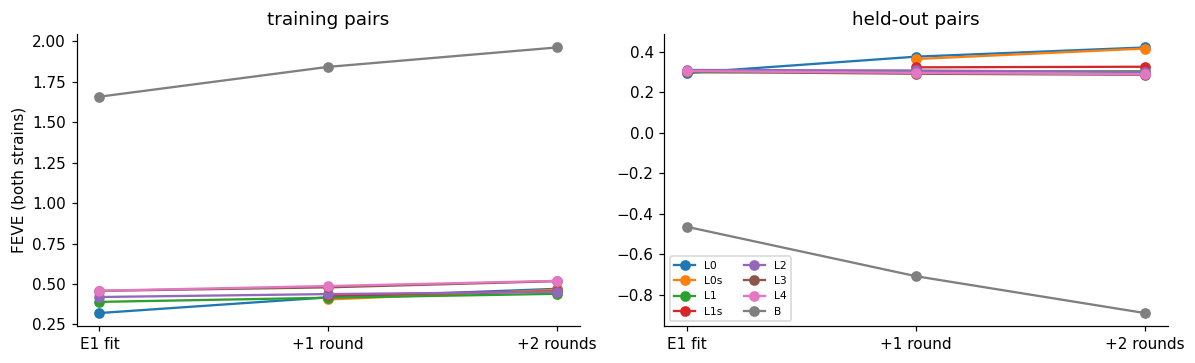

In [5]:
def cv_from(models, L):
    out = np.zeros(ds.mean.shape)
    for f, m in enumerate(models):
        msk = folds[f].reshape(folds[f].shape + (1,) * (ds.mean.ndim - 3))
        out = np.where(msk, full_pred(L, m[L]), out)
    return out
def train_feve(r, models, L):
    return float(np.mean([tf(r, f, L, m[L]) for f, m in enumerate(models)]))
ROUNDS = {"E1": E1_FITS, "r1": R1, "r2": R2}
PR, TR = {}, {}
for r, models in ROUNDS.items():
    PR[r], TR[r] = {}, {}
    for L in RUNGS:
        if L not in models[0]: continue
        PR[r][L] = E1_PRED[L] if (r == "E1" and E1_PRED is not None) else cv_from(models, L)
        TR[r][L] = train_feve(r, models, L)
HO = {r: {L: float(M_.feve(PR[r][L], ds)) for L in PR[r]} for r in PR}
print(f"{'':6s}" + "".join(f"{L:>16s}" for L in RUNGS))
for kind, tab in (("train", TR), ("held", HO)):
    for r in ROUNDS:
        print(f"{kind:5s} {r:3s}" + "".join(f"{tab[r][L]:16.3f}" if L in tab[r] else f"{'—':>16s}" for L in RUNGS))
gain_train = {L: TR["r2"][L] - TR["r1"][L] for L in RUNGS}
CONVERGED = bool(max(gain_train.values()) < 0.01)
print("\ntraining FEVE gain, round 1 -> 2:", {L: round(v, 4) for L, v in gain_train.items()})
print("Registered rule -> CONVERGED:", CONVERGED)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, tab, title in ((ax[0], TR, "training pairs"), (ax[1], HO, "held-out pairs")):
    for L in RUNGS:
        xs = [i for i, r in enumerate(ROUNDS) if L in tab[r]]
        a.plot(xs, [tab[list(ROUNDS)[i]][L] for i in xs], "o-", label=L)
    a.set_xticks(range(3)); a.set_xticklabels(["E1 fit", "+1 round", "+2 rounds"]); a.set_title(title)
ax[0].set_ylabel("FEVE (both strains)"); ax[1].legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

## 3 · E1's rules on the fairly fitted ladder

In [6]:
def decide(preds, ladder, strain=None):
    point, boots = M_.bootstrap_feve(preds, ds, list(ladder) + ["B"], n_boot=N_BOOT, seed=0, strain=strain)
    suff = M_.closure_decision(point, boots, ladder=ladder, threshold=THRESHOLD, blackbox="B")
    nec = M_.necessity(point, boots, ladder=ladder)
    v4 = {"delta=0": M_.calibrated_closure(boots, 0.0, ladder)["L_closed"]}
    v4.update({f"delta[{k}]={d:.3f}": M_.calibrated_closure(boots, d, ladder)["L_closed"] for k, d in DELTA.items()})
    return dict(point=point, boots=boots, L_star=suff["L_star"], L_needed=nec["L_needed"], v4=v4, nec=nec)
RES = {"E1 original": decide(PR["E1"], LADDER0), "r1 extended": decide(PR["r1"], LADDER2),
       "r2 original": decide(PR["r2"], LADDER0), "r2 extended": decide(PR["r2"], LADDER2),
       "r2 original WT": decide(PR["r2"], LADDER0, "wt"), "r2 extended WT": decide(PR["r2"], LADDER2, "wt")}
for k, r in RES.items():
    lad_ = LADDER2 if "extended" in k else LADDER0
    print(f"{k:15s}: FEVE " + " ".join(f"{L}={r['point'][L]:.3f}" for L in lad_ + ("B",)))
    print(f"{'':15s}  L* = {r['L_star']} | L_needed = {r['L_needed']} | v4 = {r['v4']}")
print(); print(M_.format_necessity(RES["r2 extended"]["nec"]))
key = lambda r: (r["L_star"], r["L_needed"], tuple(sorted(r["v4"].items())))
DECISIONS_STABLE = key(RES["r1 extended"]) == key(RES["r2 extended"])
fin = RES["r2 extended"]
VERDICT_L0 = bool(fin["L_needed"] == "L0" and all(v == "L0" for v in fin["v4"].values()))
b, pt = fin["boots"], fin["point"]; TESTS = {}
for x, y in (("L0s", "L0"), ("L1s", "L1"), ("L1", "L0"), ("L1s", "L0"), ("L2", "L1"), ("L3", "L1"), ("L4", "L1")):
    d = b[x] - b[y]; TESTS[f"{x}-{y}"] = (float(pt[x] - pt[y]), [float(v) for v in np.percentile(d, [2.5, 97.5])])
    print(f"  {x:3s} - {y:3s}: {TESTS[f'{x}-{y}'][0]:+.4f}  95% CI [{TESTS[f'{x}-{y}'][1][0]:+.4f}, {TESTS[f'{x}-{y}'][1][1]:+.4f}]")
SLOW_HELPS_L0 = TESTS["L0s-L0"][1][0] > 0; SLOW_HELPS_L1 = TESTS["L1s-L1"][1][0] > 0
print("Registered rules -> DECISIONS_STABLE:", DECISIONS_STABLE, "| VERDICT_L0:", VERDICT_L0,
      "| SLOW_HELPS_L0:", SLOW_HELPS_L0, "| SLOW_HELPS_L1:", SLOW_HELPS_L1)

E1 original    : FEVE L0=0.295 L1=0.298 L2=0.310 L3=0.301 L4=0.304 B=-0.464
                 L* = L1 | L_needed = L0 | v4 = {'delta=0': 'L0', 'delta[repeat]=0.000': 'L0', 'delta[long]=0.003': 'L0'}
r1 extended    : FEVE L0=0.375 L0s=0.364 L1=0.302 L1s=0.323 L2=0.307 L3=0.291 L4=0.296 B=-0.707
                 L* = L0 | L_needed = L0 | v4 = {'delta=0': 'L0', 'delta[repeat]=0.000': 'L0', 'delta[long]=0.003': 'L0'}
r2 original    : FEVE L0=0.421 L1=0.303 L2=0.300 L3=0.286 L4=0.288 B=-0.889
                 L* = L0 | L_needed = L0 | v4 = {'delta=0': 'L0', 'delta[repeat]=0.000': 'L0', 'delta[long]=0.003': 'L0'}
r2 extended    : FEVE L0=0.421 L0s=0.415 L1=0.303 L1s=0.326 L2=0.300 L3=0.286 L4=0.288 B=-0.889
                 L* = L0 | L_needed = L0 | v4 = {'delta=0': 'L0', 'delta[repeat]=0.000': 'L0', 'delta[long]=0.003': 'L0'}
r2 original WT : FEVE L0=0.374 L1=0.269 L2=0.262 L3=0.298 L4=0.302 B=0.153
                 L* = L0 | L_needed = L0 | v4 = {'delta=0': 'L0', 'delta[repeat]=0.000': 'L0'

## 4 · The black box, fairly fitted (both strains and wild type)

r2 extended: L* = L0; FEVE(B) - FEVE(L*) = -1.3098  95% CI [-1.8419, -0.9726]
                 FEVE(B) - best rung per draw = -1.3384  95% CI [-1.8419, -0.9734]
r2 extended WT: L* = L0; FEVE(B) - FEVE(L*) = -0.2210  95% CI [-0.3087, -0.1501]
                 FEVE(B) - best rung per draw = -0.2238  95% CI [-0.3087, -0.1501]
  strain wt    : B +0.153 | L0 +0.374 | L1 +0.269
  strain unc31 : B -3.108 | L0 +0.520 | L1 +0.377
Registered rules -> OUTCOME_C: False | OUTCOME_C_WT: False


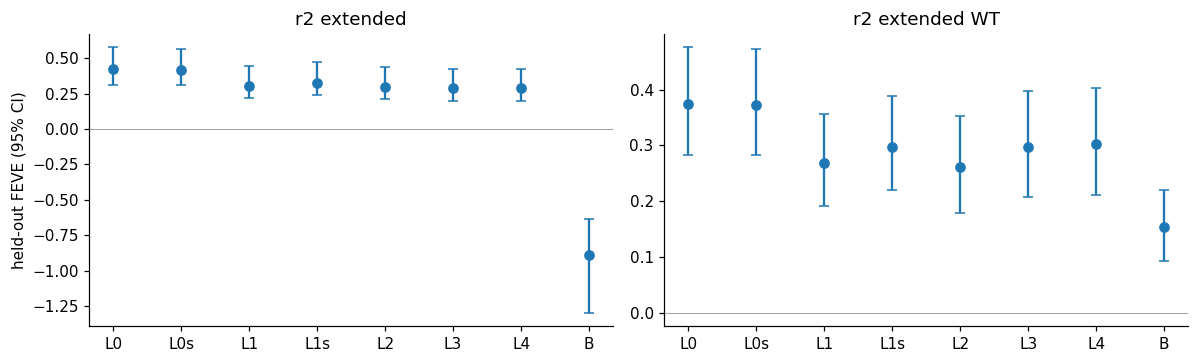

In [7]:
OC = {}
for k, name in (("r2 extended", "OUTCOME_C"), ("r2 extended WT", "OUTCOME_C_WT")):
    r = RES[k]; bw, pw = r["boots"], r["point"]; Ls = r["L_star"]
    best = np.max(np.stack([bw[L] for L in LADDER2]), axis=0); db = bw["B"] - best
    if Ls is None:
        OC[name] = False; ci = [np.nan, np.nan]; print(f"{k}: no sufficiency L* -> the black-box rule does not apply")
    else:
        ci = np.percentile(bw["B"] - bw[Ls], [2.5, 97.5]); OC[name] = bool(ci[0] > THRESHOLD)
        print(f"{k}: L* = {Ls}; FEVE(B) - FEVE(L*) = {pw['B'] - pw[Ls]:+.4f}  95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}]")
    print(f"{'':15s}  FEVE(B) - best rung per draw = {np.mean(db):+.4f}  95% CI [{np.percentile(db, 2.5):+.4f}, {np.percentile(db, 97.5):+.4f}]")
    OC[name + "_detail"] = {"L_star": Ls, "B_minus_Lstar_ci": [float(x) for x in ci],
                            "B_minus_best": [float(np.mean(db)), float(np.percentile(db, 2.5)), float(np.percentile(db, 97.5))]}
for s in ds.strains:
    p_s = M_.bootstrap_feve({L: PR["r2"][L] for L in ("B", "L0", "L1")}, ds, ["B", "L0", "L1"], n_boot=200, seed=0, strain=s)[0]
    print(f"  strain {s:6s}: B {p_s['B']:+.3f} | L0 {p_s['L0']:+.3f} | L1 {p_s['L1']:+.3f}")
OUTCOME_C, OUTCOME_C_WT = OC["OUTCOME_C"], OC["OUTCOME_C_WT"]
print("Registered rules -> OUTCOME_C:", OUTCOME_C, "| OUTCOME_C_WT:", OUTCOME_C_WT)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, k in ((ax[0], "r2 extended"), (ax[1], "r2 extended WT")):
    r = RES[k]; lab = list(LADDER2) + ["B"]
    mu = [r["point"][L] for L in lab]; lo = [np.percentile(r["boots"][L], 2.5) for L in lab]; hi = [np.percentile(r["boots"][L], 97.5) for L in lab]
    a.errorbar(range(len(lab)), mu, yerr=[np.subtract(mu, lo), np.subtract(hi, mu)], fmt="o", capsize=3)
    a.set_xticks(range(len(lab))); a.set_xticklabels(lab); a.set_title(k); a.axhline(0, c="0.6", lw=0.6)
ax[0].set_ylabel("held-out FEVE (95% CI)"); plt.tight_layout(); plt.show()

In [8]:
out = {"source": SOURCE, "steps_per_round": STEPS, "round1_sources": R1_FROM, "kept_start": KEPT_START,
       "CONVERGED": CONVERGED, "DECISIONS_STABLE": DECISIONS_STABLE, "VERDICT_L0": VERDICT_L0,
       "SLOW_HELPS_L0": bool(SLOW_HELPS_L0), "SLOW_HELPS_L1": bool(SLOW_HELPS_L1), "OUTCOME_C": OUTCOME_C, "OUTCOME_C_WT": OUTCOME_C_WT,
       "train_feve": TR, "heldout_feve": HO, "train_gain_r1_r2": gain_train, "tests_r2": TESTS,
       "decisions": {k: {"feve": {L: float(v) for L, v in r["point"].items()}, "L_star": r["L_star"], "L_needed": r["L_needed"], "v4": r["v4"]}
                     for k, r in RES.items()},
       "blackbox": {k: v for k, v in OC.items() if k.endswith("_detail")}}
json.dump(out, open(os.path.join(RESULTS, f"E1l_result{TAG}.json"), "w"), indent=2, default=float)
np.savez_compressed(os.path.join(RESULTS, f"E1l_heldout_predictions{TAG}.npz"), **{L: PR["r2"][L] for L in RUNGS})
print("saved", f"E1l_result{TAG}.json and E1l_heldout_predictions{TAG}.npz (round-2 held-out predictions)")

saved E1l_result_laptop.json and E1l_heldout_predictions_laptop.npz (round-2 held-out predictions)


## Results (laptop mode, run on the M1 Mac)

**Refinement.** All 20 new round-1 fits and 40 round-2 fits ran (25–165 s each). The guard never fired: no round lowered a model's training fit. After round 2 the slow currents sit at ρ ≈ 0.10–0.13 for `L0s` and ρ ≈ 0.20–0.26 for `L1s`; τ_n again did not move from its start.

**FEVE by round (both strains)**

| | L0 | L0s | L1 | L1s | L2 | L3 | L4 | B |
|---|---|---|---|---|---|---|---|---|
| training, E1 fit | 0.321 | — | 0.389 | — | 0.419 | 0.457 | 0.458 | 1.657 |
| training, round 1 | 0.417 | 0.405 | 0.415 | 0.430 | 0.438 | 0.479 | 0.487 | 1.841 |
| training, round 2 | 0.470 | 0.464 | 0.439 | 0.454 | 0.451 | 0.517 | 0.520 | 1.961 |
| **held-out**, E1 fit | 0.295 | — | 0.298 | — | 0.310 | 0.301 | 0.304 | −0.464 |
| **held-out**, round 1 | 0.375 | 0.364 | 0.302 | 0.323 | 0.307 | 0.291 | 0.296 | −0.707 |
| **held-out**, round 2 | **0.421** | 0.415 | 0.303 | 0.326 | 0.300 | 0.286 | 0.288 | −0.889 |

* **CONVERGED = False.** Training FEVE still rises from round 1 to 2 for every model: L0 +0.053, L0s +0.059, L1/L1s +0.024, L2 +0.014, L3 +0.038, L4 +0.032, B +0.120.
* **What keeps moving differs by model, and that decides the reading.**
  * **L0 improves on held-out pairs as much as on training pairs** (0.295 → 0.375 → 0.421). It is under-fitted, not over-fitted.
  * **L2, L3 and L4 get worse on held-out pairs as they improve on training pairs.** They are over-fitting: L3 0.301 → 0.286, L4 0.304 → 0.288. L1 is flat.
  * **The black box over-fits extremely.** Its training FEVE is above 1, meaning it fits trial-to-trial noise, while held-out FEVE falls to −0.889.

**E1's rules, round 2**

| ladder | L\* | L_needed | v4 (every δ) |
|---|---|---|---|
| E1 original (Notebook 04) | L1 | L0 | L0 |
| round 1, extended | **L0** | **L0** | **L0** |
| round 2, original (L0–L4) | **L0** | **L0** | **L0** |
| round 2, extended | **L0** | **L0** | **L0** |
| round 2, WT only | **L0** | **L0** | **L0** |

* **DECISIONS_STABLE = True, VERDICT_L0 = True.** Every deeper rung is now significantly **worse** than the best shallower one (necessity table): L1 −0.116 [−0.218, −0.035], L1s −0.093, L2 −0.120, L3 −0.133, L4 −0.131. All upper CI bounds are below 0.
* **SLOW_HELPS_L0 = False:** `L0s` − L0 = −0.005 [−0.011, −0.000]. **SLOW_HELPS_L1 = True:** `L1s` − L1 = +0.022 [+0.010, +0.040], as in Notebook 22. The slow current helps the nonlinear family, but that whole family is 0.1 below L0.
* **OUTCOME_C = False, OUTCOME_C_WT = False.** B − L0 is −1.31 [−1.84, −0.97] on both strains and **−0.221 [−0.309, −0.150] on WT**. B's apparent WT lead (Notebook 23) is gone entirely.
* Per strain (round 2): WT L0 0.374, L1 0.269, B 0.153; unc-31 **L0 0.520**, L1 0.377, B −3.11.

**What this means.**
1. **The observed row is "CONVERGED no / VERDICT_L0 yes"**, but the non-convergence does not make the verdict provisional.
   * The model still improving is the winner. The models that keep training are losing held-out accuracy.
   * Give every nonlinear rung its best round **chosen in hindsight on the test pairs** (biased in their favour): L1s 0.326, L2 0.310, L4 0.304, L1 0.303, L3 0.301. That is still 0.05 below L0's *round-1* score and 0.10 below its round-2 score.
   * More training of the kind E1 used cannot reverse the ordering. What remains open is *how good* L0 gets, not whether it wins.
2. **E1's verdict, fairly fitted: the closed level under single-neuron stimulation is L0.** That is linear dynamics on the signed connectome, with three sign-class weights, one gap conductance, one time constant and per-neuron read-out gains. Every richer description predicts held-out responses worse, the black box included.
3. **Why do richer rungs lose? The ladder confounds two changes.** L1 adds a **nonlinearity** (sigmoid synapses, per-neuron operating points). It also replaces L0's three class weights by **synapse-resolved weights**, one per connected class pair, so hundreds more parameters. The pattern above (training up, held-out down) is over-fitting, which points at the second change. But nothing here separates them.
4. **Notebook 26 (E1m)** separates them with a 2 × 2 of models:
   * linear vs nonlinear × class weights vs synapse weights: L0, `L1c`, `L0w`, L1;
   * every model stopped by a validation rule (early stopping on an inner split of the training pairs) instead of a fixed budget, which also settles how far L0 can go.


## 5 · Reading the result

| CONVERGED | VERDICT_L0 | reading for C2 |
|---|---|---|
| yes | yes | **E1's verdict survives fair fitting.** Once every rung is near its family's optimum, nothing beyond the signed wiring is needed to predict responses to single-neuron stimulation. This holds for the static nonlinearity, adaptation, peptides, homeostasis and a slow current alike. The best description of the atlas is **linear dynamics on the connectome**. For C2: the system is closed at L0 under this intervention, at the precision of the data. |
| yes | no | Fair fitting **reveals a mechanism** that E1's unequal fits hid. The necessity table shows which rung, and its gain over L0 is the size of the effect. This is the first positive evidence for a level above the wiring; it calls for a confirmatory experiment on that mechanism (Notebook 08's design). |
| no | either | **← observed (with VERDICT_L0 = yes)**; see Results: the model still moving is L0, upwards, while the others over-fit, so the verdict is not provisional. Original reading: the fits are still moving after two rounds; the decision is **provisional**. Rerun in `full` mode (1000 steps per round). If a rung gained on training but lost on held-out pairs, it is overfitting, and E1 would need early stopping on an inner validation split. |

| OUTCOME_C (both / WT) | reading |
|---|---|
| no / no | **← observed** (B − L0 = −0.22 on WT). The black box does not beat the fairly fitted ladder by E1's margin anywhere. Outcome A/B stands: whatever predicts the responses is captured by the mechanistic ladder. |
| no / yes | On wild type something systematic is missed, and the ladder cannot capture it. Look at the least-explained neurons (pharyngeal, gas-sensing; Notebook 04). |

**Limits.**
* "Fair" means equal *extra* budget after E1, from E1's starts. L1 had 3 restarts in E1 and L0 had one, and nothing here samples new starts. A rung stuck in a poor basin stays there unless 600 steps of warm-restarted Adam get it out, as they did for L0.
* `laptop` mode is the 120 most-sampled neurons. The registered E1 test is `full` mode on all 300.
* Held-out FEVE is computed on the same folds that guided the decision to refine (Notebook 24). The refinement itself uses training pairs only.